# T01 - Caminata Aleatoria

#### 1. Simulación del movimiento browniano

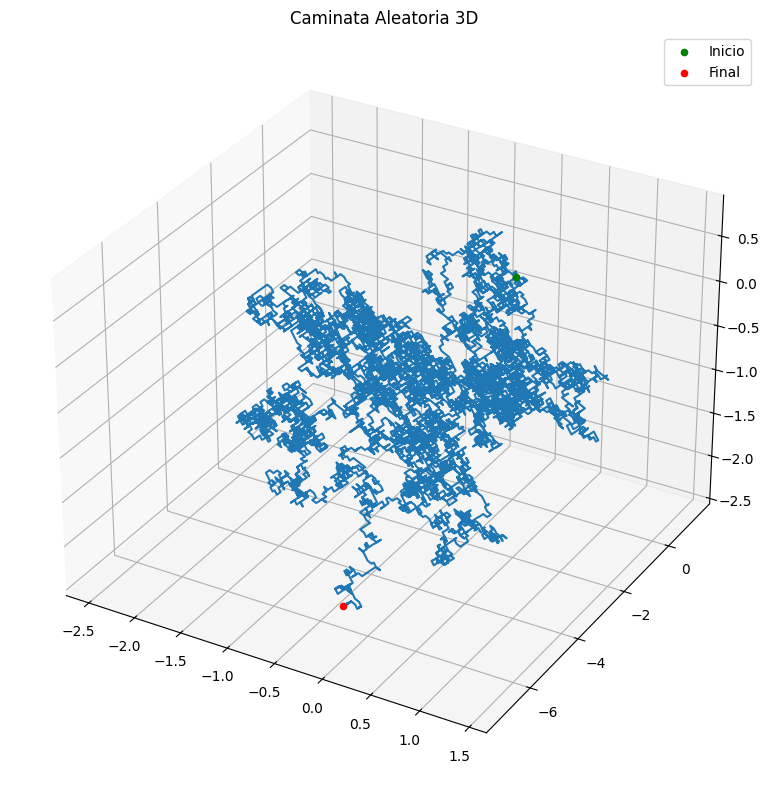

In [84]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(100)

def caminata_aleatoria(T, dt):
    Pasos = int(T/dt)
    path_x =[0]
    path_y = [0]
    path_z = [0]
    for i in range(1,Pasos+1):
        Xi = np.random.choice([-1, 1])
        Yi = np.random.choice([-1, 1])
        Zi = np.random.choice([-1, 1])
        path_x.append(path_x[i-1] + Xi * np.sqrt(dt))
        path_y.append(path_y[i-1] + Yi * np.sqrt(dt))
        path_z.append(path_z[i-1] + Zi * np.sqrt(dt))
    return path_x, path_y, path_z

path_x, path_y, path_z = caminata_aleatoria(10, 0.001)
path_x = np.array(path_x)
path_y = np.array(path_y)
path_z = np.array(path_z)

plt.figure(figsize=(10, 8))
plt.axes(projection='3d')
plt.plot(path_x, path_y, path_z)
plt.gca().scatter(path_x[0], path_y[0], path_z[0],  label='Inicio',color='green')
plt.gca().scatter(path_x[-1], path_y[-1], path_z[-1], label='Final',color='red')
plt.title('Caminata Aleatoria 3D')
plt.legend()
plt.tight_layout()
plt.show()

#### 2.- Apuesta Arriesgada

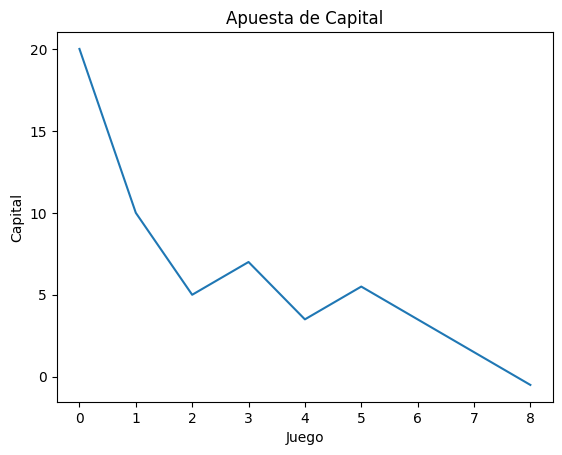

In [85]:
#Evolucion del capital hasta quedar en 0

def apuesta(capital_inicial):
    hist = [capital_inicial]
    juego = 0
    while capital_inicial > 0:
        apuesta = capital_inicial/2 if capital_inicial >= 6 else 2
        moneda = np.random.choice([1,-1])
        capital_inicial += apuesta * moneda
        hist.append(capital_inicial)
        juego += 1
    return hist, juego

hist, juego = apuesta(20)

plt.plot(range(juego+1), hist)
plt.title('Apuesta de Capital')
plt.xlabel('Juego')
plt.ylabel('Capital')
plt.show()




In [86]:
# Número de volados promedio para quedar en quiebra
volados = []
for i in range(10000):
    hist, juego = apuesta(20)
    volados.append(juego)

print(f"Volados promedio para quedar en quiebra es: {np.mean(volados)}")

Volados promedio para quedar en quiebra es: 26.6158


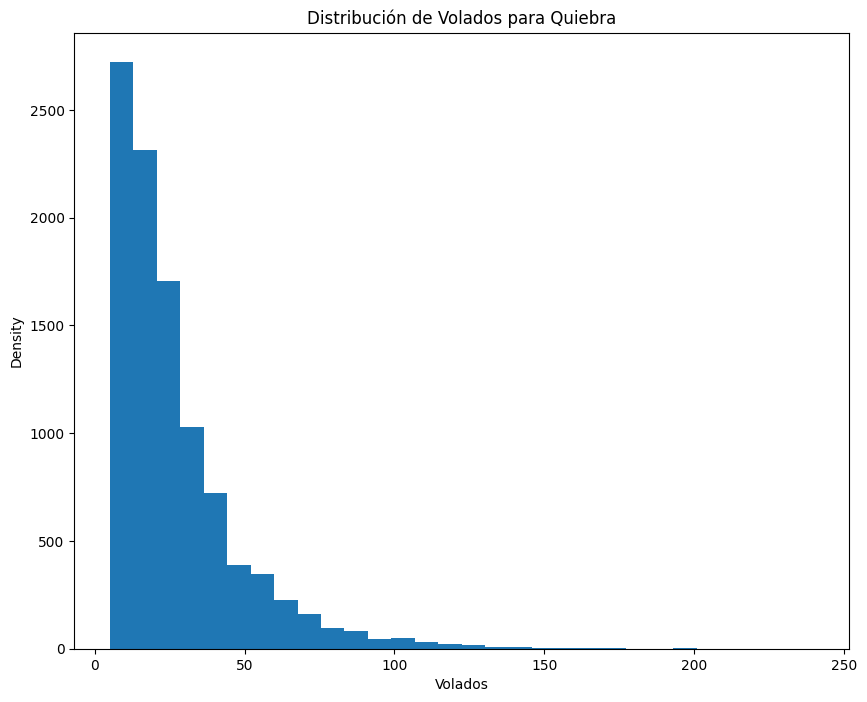

In [87]:
# Histograma del número de volados
plt.figure(figsize=(10, 8))
plt.hist(volados, bins=30)
plt.title('Distribución de Volados para Quiebra')
plt.xlabel('Volados')
plt.ylabel('Density')
plt.show()